In [663]:
!pip install -r requirements.txt

In [664]:
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error, \
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, log_loss
from sklearn.utils import resample


### Разведочный анализ данных

Считываем датасет и выводим его общую информацию.

In [665]:
df = pd.DataFrame(pd.read_csv('./student_lifestyle_100k.csv', sep=','))
print(df.head())
df.info()

   Student_ID  Age  Gender   Department  CGPA  Sleep_Duration  Study_Hours  \
0        1001   22  Female      Science  3.50             7.3          3.3   
1        1002   20    Male  Engineering  2.72             5.5          7.2   
2        1003   20    Male      Medical  3.01             5.4          2.3   
3        1004   21    Male  Engineering  3.63             8.1          2.0   
4        1005   19    Male         Arts  3.14             6.8          2.6   

   Social_Media_Hours  Physical_Activity  Stress_Level  Depression  
0                 3.4                114             5       False  
1                 6.0                142             2       False  
2                 1.8                137             3       False  
3                 4.6                130             3       False  
4                 4.3                  4             6       False  
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 11 columns):
 #   Column       

Удаляем столбец с идентификаторами студентов, а также дубликаты и строки с пропущенными значениями. Выводим информацию о новом датафрейме. Ничего не удалилось, так как датасет слишком идеальный :)

In [666]:
df = df.drop(columns=['Student_ID'])
df = df.drop_duplicates().dropna()
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Age                 100000 non-null  int64  
 1   Gender              100000 non-null  str    
 2   Department          100000 non-null  str    
 3   CGPA                100000 non-null  float64
 4   Sleep_Duration      100000 non-null  float64
 5   Study_Hours         100000 non-null  float64
 6   Social_Media_Hours  100000 non-null  float64
 7   Physical_Activity   100000 non-null  int64  
 8   Stress_Level        100000 non-null  int64  
 9   Depression          100000 non-null  bool   
dtypes: bool(1), float64(4), int64(3), str(2)
memory usage: 7.0 MB


Выводим графики числовых столбцов в виде гисторамм и боксплотов

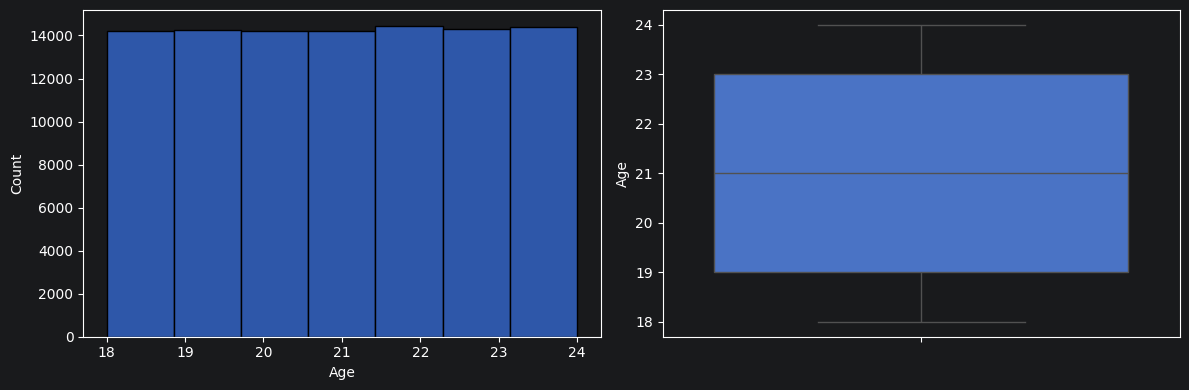

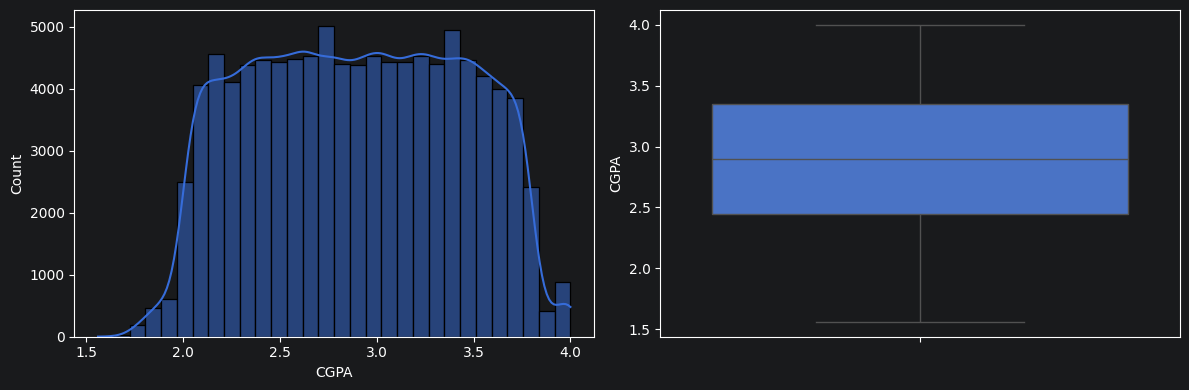

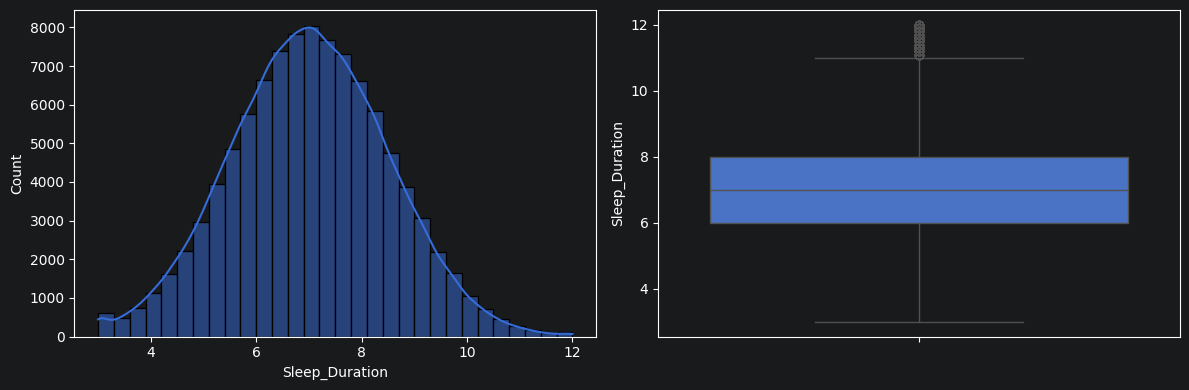

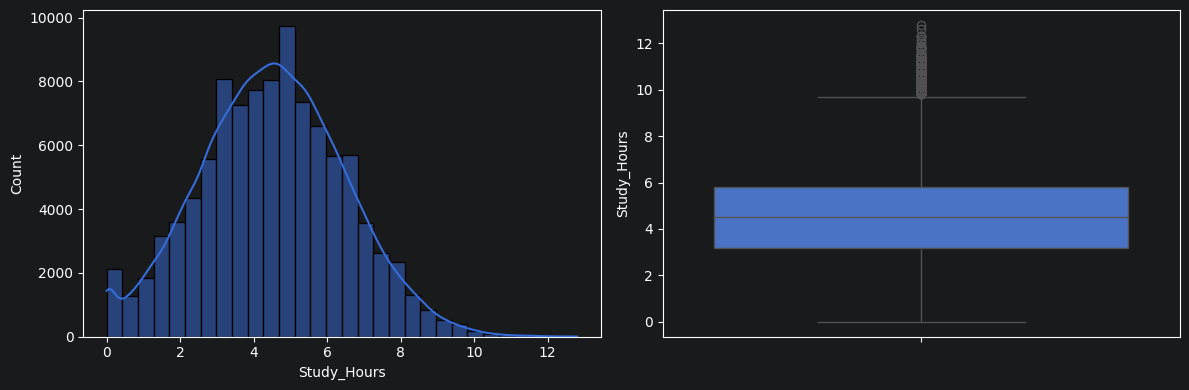

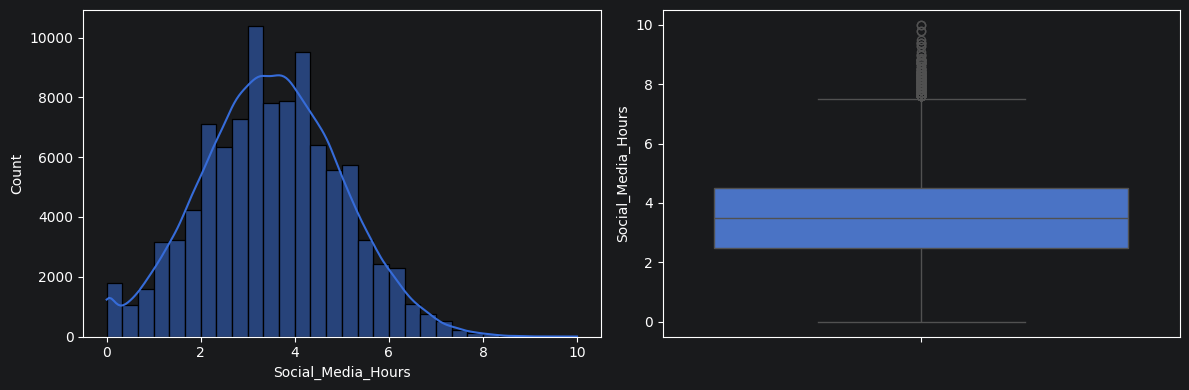

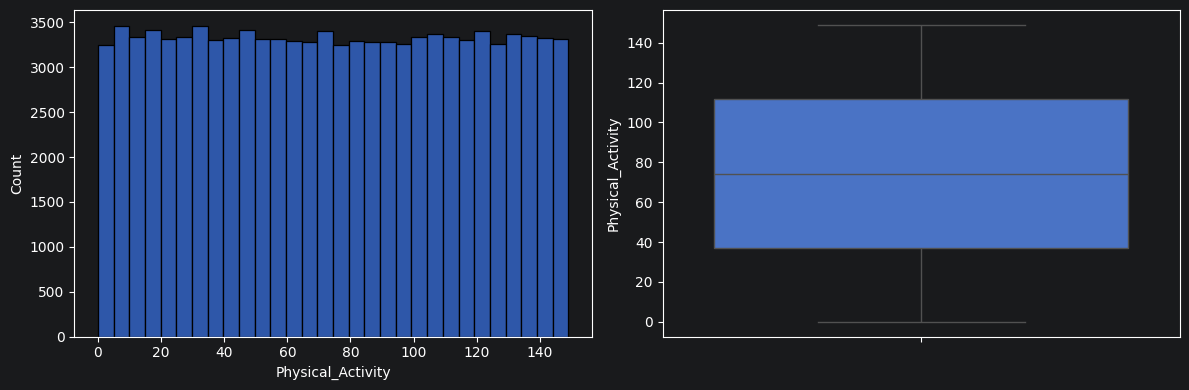

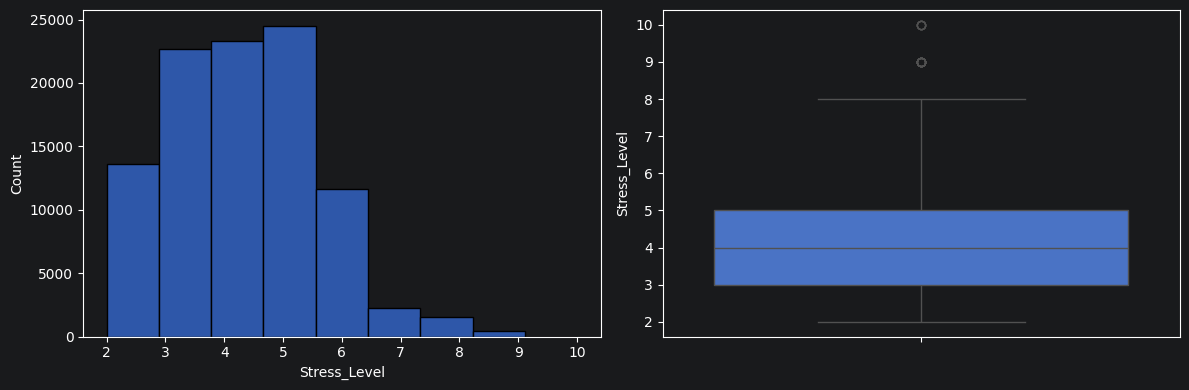

In [667]:
numeric_columns = df.select_dtypes(include=[np.number]).columns


def create_histplot_boxplot(df, column):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    if df[column].dtype == int:
        sns.histplot(data=df, x=column, bins=min(30, df[column].unique().size), ax=axes[0])
    else:
        sns.histplot(data=df, x=column, bins=30, kde=True, ax=axes[0])
    sns.boxplot(df[column], ax=axes[1])

    plt.tight_layout()
    plt.show()


for column in numeric_columns:
    create_histplot_boxplot(df, column)


Вывод по графикам числовых столбцов:
- **Age** - распределение практически равномерное
- **CGPA** - распределение похоже на нормальное, с небольшим смещением влево
- **Sleep_Duration** - распределение похоже на нормальное. По бкосплоту видно, что существуют выбросы сверху.
- **Study_Hours** - распределение похоже на нормальное, с небольшим смещением влево. Также с выбросами сверху.
- **Social_Media_Hours** - распределение похоже на нормальное, с небольшим смещением влево. С выбросами сверху.
- **Physical_Activity_Hours** - распределение практически равномерное
- **Stress_Level** - распределение, похожее на распределение Пуассона. С выбросами в значениях 9 и 10.

Выводим также графики для категориальных столбцов

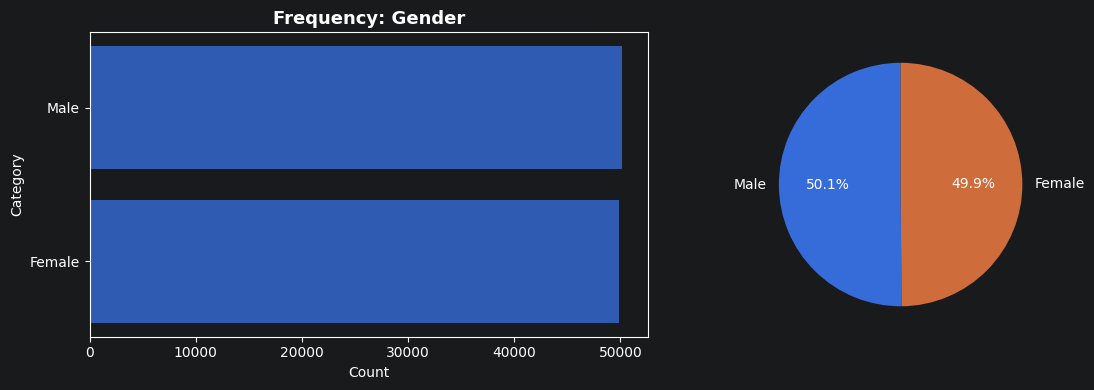

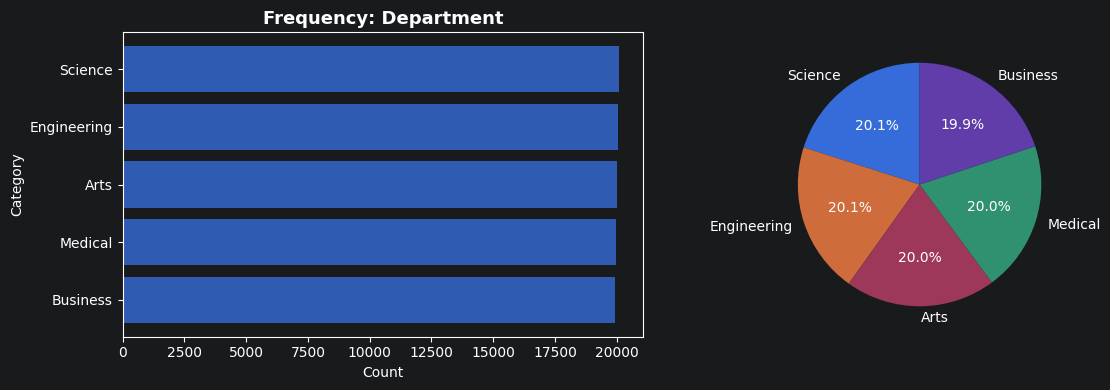

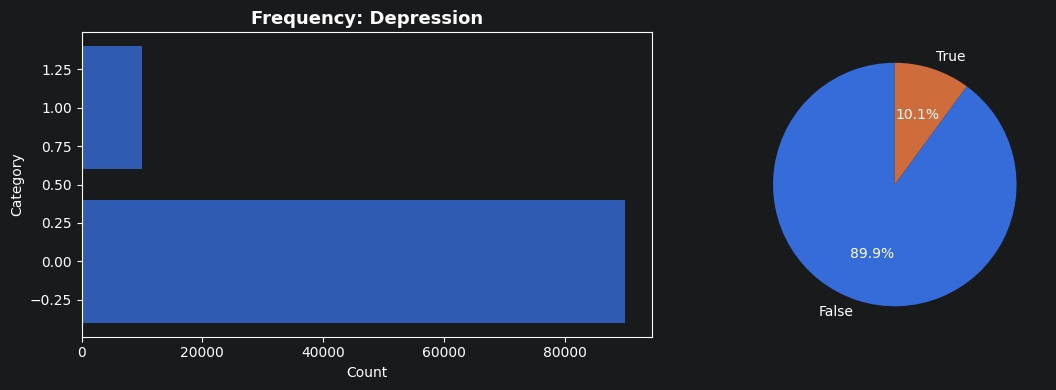

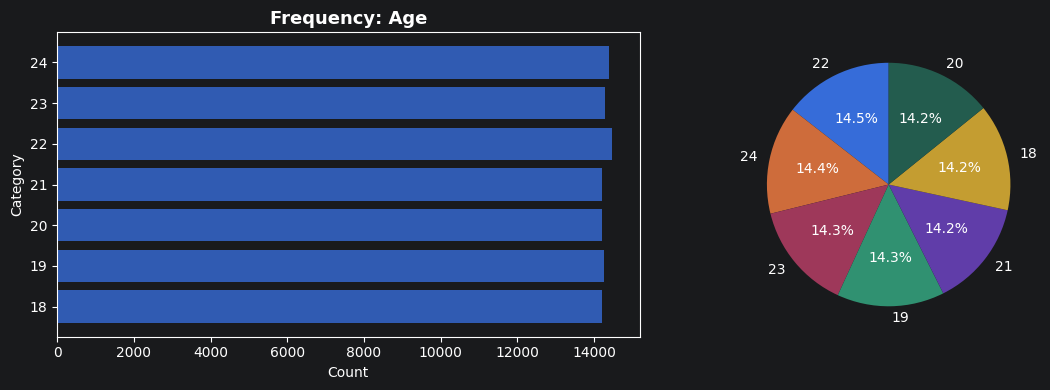

In [668]:
def create_bar_pie_charts(df, column):
    value_counts = df[column].value_counts()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].barh(value_counts.index[::-1], value_counts.values[::-1], alpha=0.8)
    axes[0].set_title(f'Frequency: {column}', fontsize=13, fontweight='bold')
    axes[0].set_xlabel('Count')
    axes[0].set_ylabel('Category')

    axes[1].pie(
        value_counts.values,
        labels=value_counts.index,
        autopct='%1.1f%%',
        startangle=90,
    )
    plt.tight_layout()
    plt.show()


category_columns = df.select_dtypes(include=['str', 'category', 'object']).columns

for column in [*category_columns, 'Depression', "Age"]:
    create_bar_pie_charts(df, column)


In [669]:
total_time = df['Sleep_Duration'] + df['Study_Hours'] + df['Social_Media_Hours']
print((total_time > 24).sum())
df = df[total_time <= 24]
print(df.info())

79
<class 'pandas.DataFrame'>
Index: 99921 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Age                 99921 non-null  int64  
 1   Gender              99921 non-null  str    
 2   Department          99921 non-null  str    
 3   CGPA                99921 non-null  float64
 4   Sleep_Duration      99921 non-null  float64
 5   Study_Hours         99921 non-null  float64
 6   Social_Media_Hours  99921 non-null  float64
 7   Physical_Activity   99921 non-null  int64  
 8   Stress_Level        99921 non-null  int64  
 9   Depression          99921 non-null  bool   
dtypes: bool(1), float64(4), int64(3), str(2)
memory usage: 7.7 MB
None


Видим, что почти все распределения нормальные, однако людей с депрессией сильно меньше, чем без неё. Поэтому можно продублировать их до равного количества, чтобы уровнять их веса при обучении логистической модели.

In [670]:
df_with_depression = df[df["Depression"] == 1]
df_without_depression = df[df["Depression"] == 0]

df_with_depression_extended = resample(df_with_depression, replace=True, n_samples=len(df_without_depression),
                                       random_state=42)

df = pd.concat([df_with_depression_extended, df_without_depression])
print(df.info())

<class 'pandas.DataFrame'>
Index: 179728 entries, 71961 to 99999
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Age                 179728 non-null  int64  
 1   Gender              179728 non-null  str    
 2   Department          179728 non-null  str    
 3   CGPA                179728 non-null  float64
 4   Sleep_Duration      179728 non-null  float64
 5   Study_Hours         179728 non-null  float64
 6   Social_Media_Hours  179728 non-null  float64
 7   Physical_Activity   179728 non-null  int64  
 8   Stress_Level        179728 non-null  int64  
 9   Depression          179728 non-null  bool   
dtypes: bool(1), float64(4), int64(3), str(2)
memory usage: 13.9 MB
None


После уравнивания количества ещё раз просмотрим графики, чтобы убедиться, что мы не получили странных распределений.

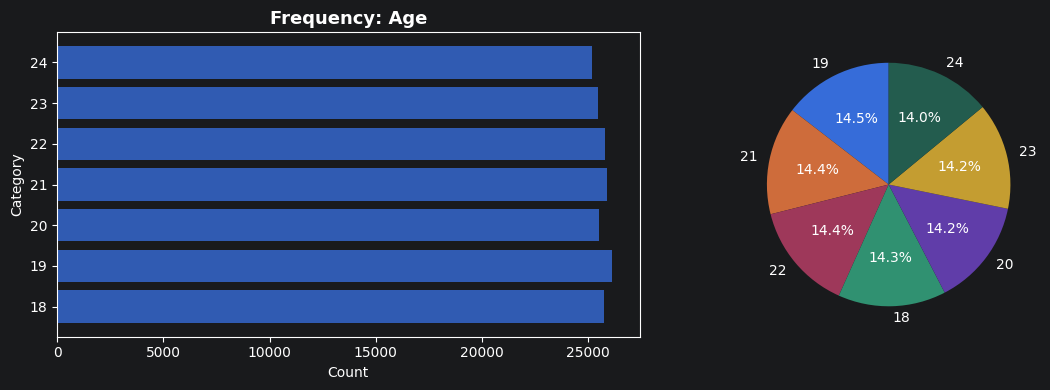

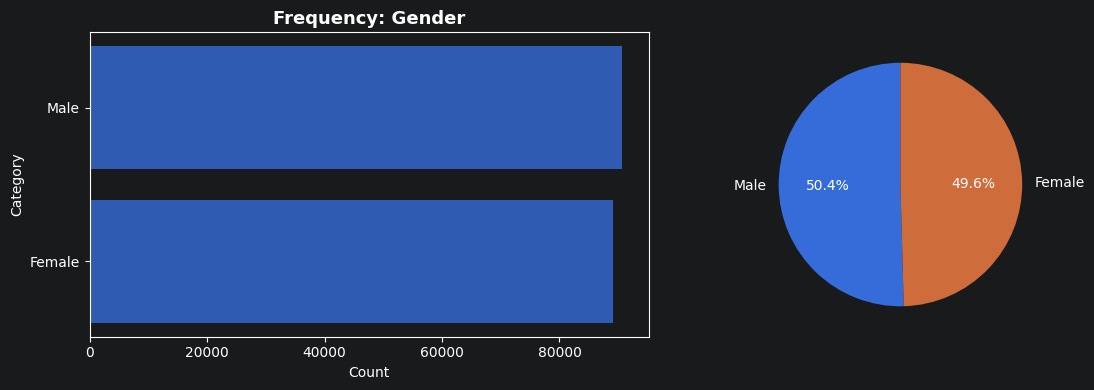

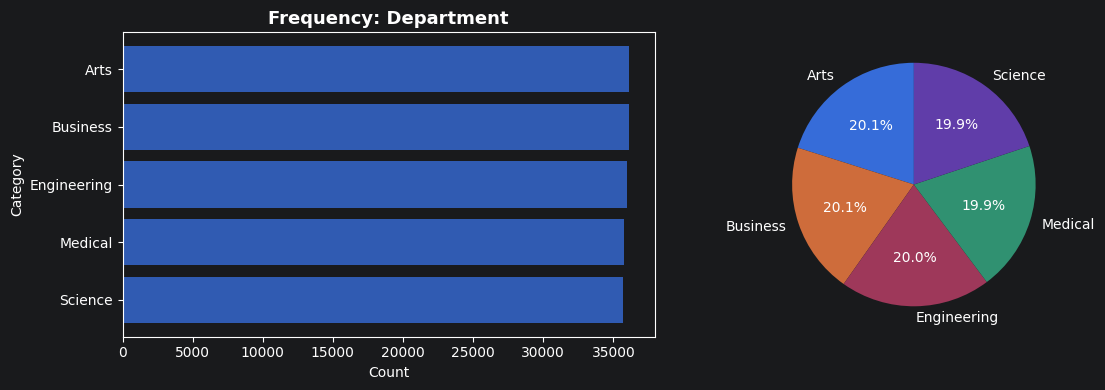

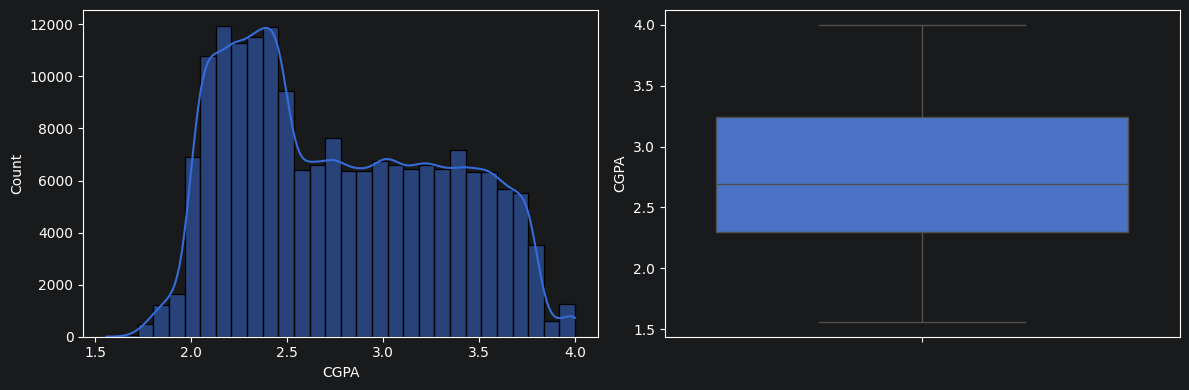

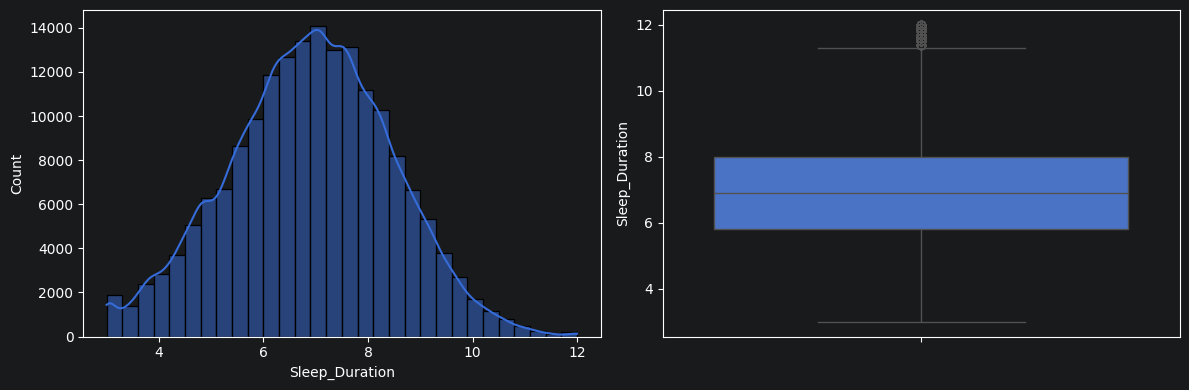

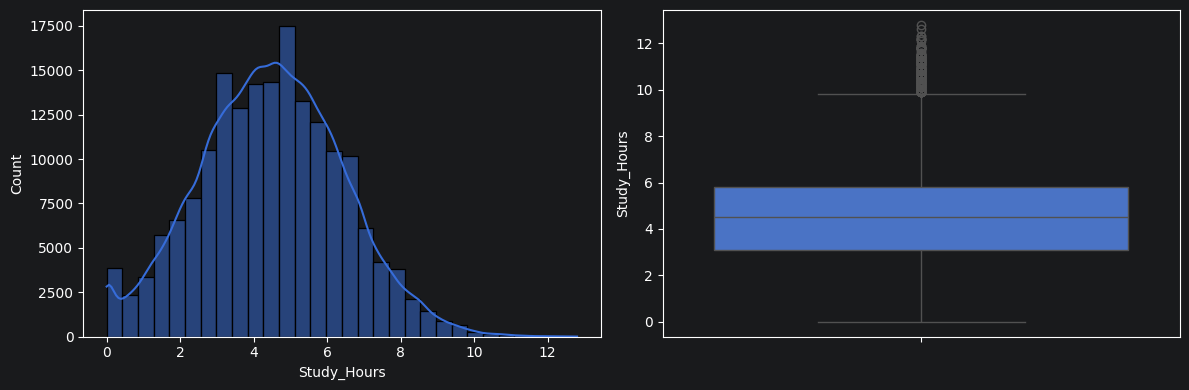

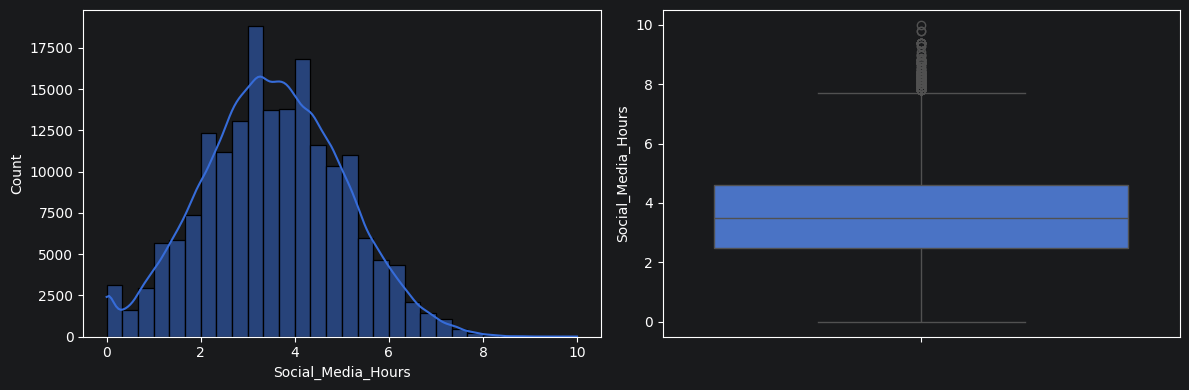

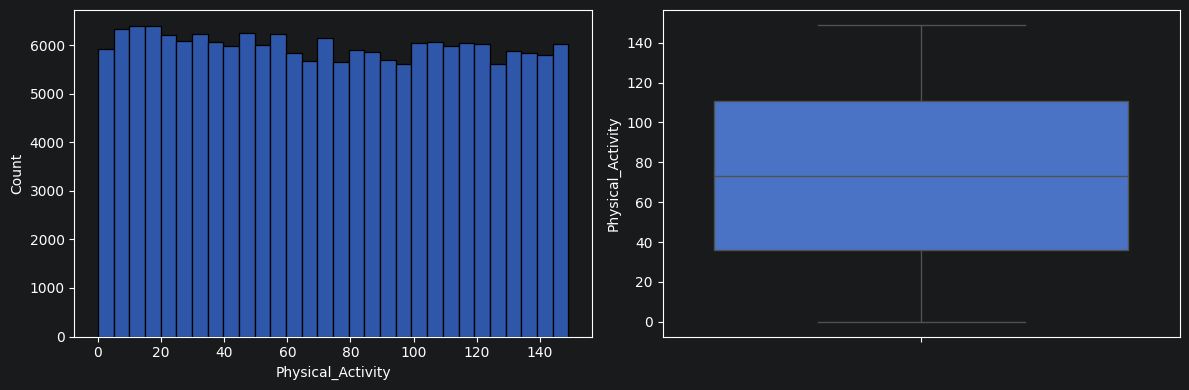

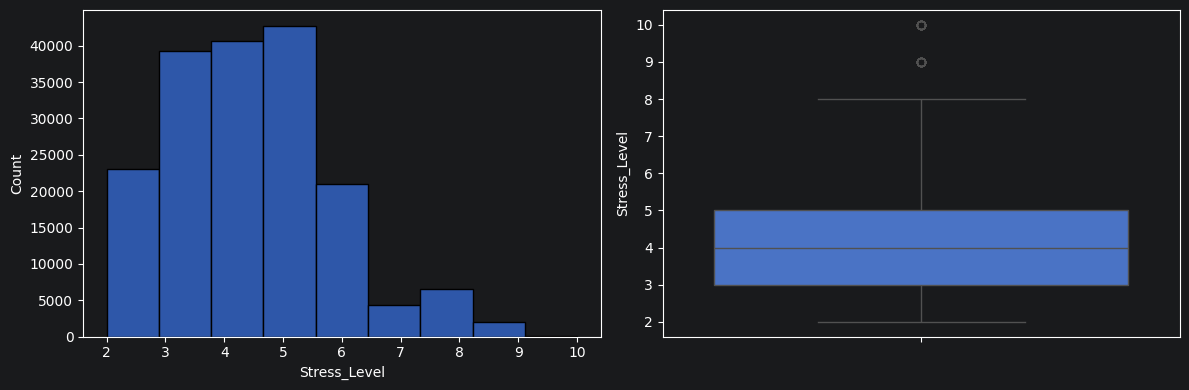

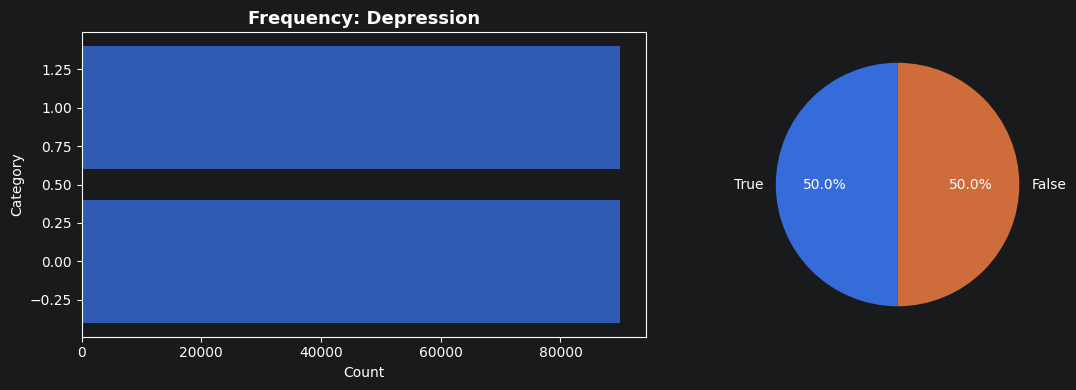

In [671]:
for column in df.columns:
    if df[column].dtype in ['str', 'category', 'object'] or df[column].unique().size < 8:
        create_bar_pie_charts(df, column)
    else:
        create_histplot_boxplot(df, column)

Видим, что существенно графики не изменилось. Однако поменялась структура графика средней оценки, это может значить, что люди с депрессией чаще имеют более низкую среднюю оценку, чем люди без депрессии.

Построим теперь график корреляции для числовых признаков, чтобы понять, какие признаки могут быть полезными для предсказания средней оценки и наличия депрессии. Также посмотрим на корреляцию между признаками и целевыми переменными.

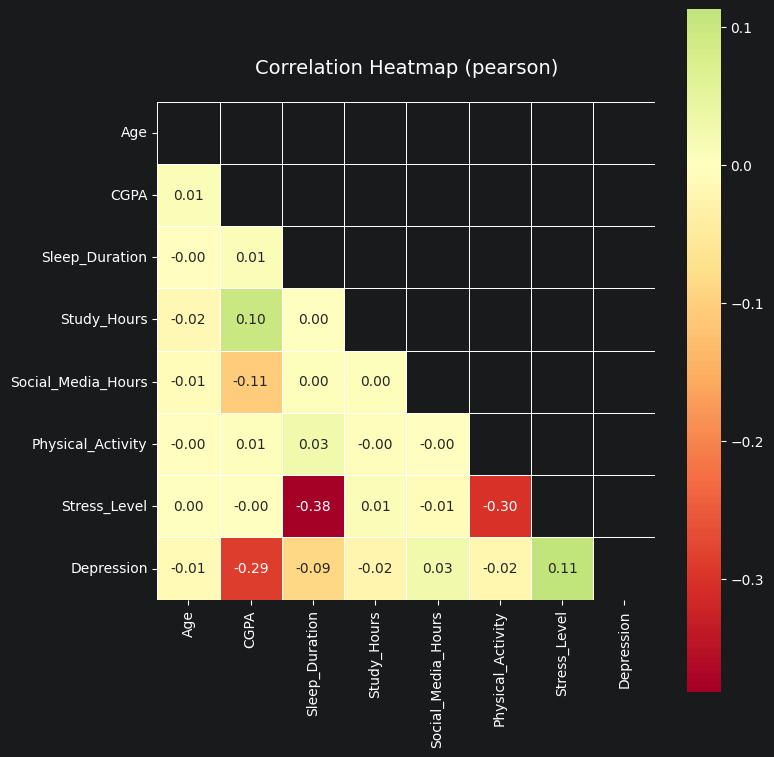

In [672]:
def plot_correlation_heatmap(df, method='pearson', threshold=0.7):
    numeric = df.select_dtypes(include=[np.number, 'bool'])
    corr = numeric.corr(method=method)

    plt.figure(figsize=(8, 8))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn', center=0, square=True, linewidths=0.5)
    plt.title(f'Correlation Heatmap ({method})', fontsize=14, pad=20)
    plt.tight_layout()
    plt.show()


plot_correlation_heatmap(df, method='pearson')

In [673]:
for column in numeric_columns:
    column_data = df[column]
    Q1 = column_data.quantile(0.25)
    Q3 = column_data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    mask = ~((df[column] < lower_bound) | (df[column] > upper_bound))
    df = df[mask]

df = df.reset_index(drop=True)
one_hot_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore', drop='first')
ohe_encoded_data = one_hot_encoder.fit_transform(df[category_columns])
dhe_df = pd.DataFrame(ohe_encoded_data, columns=one_hot_encoder.get_feature_names_out(category_columns), index=df.index)
df = df.drop(columns=category_columns)
df = pd.concat([df, dhe_df], axis=1)
print(df.head())

   Age  CGPA  Sleep_Duration  Study_Hours  Social_Media_Hours  \
0   20  2.65             5.8          5.7                 2.3   
1   19  2.26             7.6          3.0                 2.5   
2   21  2.20             8.2          3.7                 3.9   
3   22  2.99             7.0          5.2                 3.3   
4   24  2.00             5.0          5.3                 3.5   

   Physical_Activity  Stress_Level  Depression  Gender_Male  \
0                 34             4        True          1.0   
1                 31             3        True          0.0   
2                102             2        True          1.0   
3                 45             6        True          1.0   
4                 21             3        True          1.0   

   Department_Business  Department_Engineering  Department_Medical  \
0                  0.0                     0.0                 0.0   
1                  0.0                     0.0                 0.0   
2                  1

In [674]:
y = df['CGPA']
X = df[['Sleep_Duration', 'Study_Hours']]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)


def evaluate_model(y_true, y_pred, dataset_name="Dataset"):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100

    print(f"Метрики для {dataset_name}:")
    print(f"  MAE:  {mae:,.2f}")
    print(f"  RMSE: {rmse:,.2f}")
    print(f"  R²:   {r2:.4f}")
    print(f"  MAPE: {mape:.2f}%")

    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}


y_train_predict = model.predict(X_train_scaled)
y_test_predict = model.predict(X_test_scaled)

train_metrics = evaluate_model(y_train, y_train_predict, dataset_name="Train")
test_metrics = evaluate_model(y_test, y_test_predict, dataset_name="Test")

Метрики для Train:
  MAE:  0.48
  RMSE: 0.55
  R²:   0.0093
  MAPE: 17.75%
Метрики для Test:
  MAE:  0.48
  RMSE: 0.54
  R²:   0.0100
  MAPE: 17.71%


In [675]:
def evaluate_classification(y_true, y_pred, dataset_name="Dataset"):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    auc_roc = roc_auc_score(y_true, y_pred)

    print(f"Метрики для {dataset_name}:")
    print(f"  Accuracy:  {accuracy:.4f}")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    if auc_roc:
        print(f"  AUC-ROC:   {auc_roc:.4f}")
    return {'Accuracy': accuracy, 'Precision': precision, 'Recall': recall, 'F1': f1, 'AUC-ROC': auc_roc}


y = df['Depression']
X = df.drop(columns=['Depression'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

n_epochs = 10
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# loss_history = []
#
# for epoch in range(n_epochs):
#
#     y_pred_proba = model.predict_proba(X_test_scaled)
#     loss = log_loss(y_test, y_pred_proba)
#     loss_history.append(loss)

y_train_predict = model.predict(X_train_scaled)
y_test_predict = model.predict(X_test_scaled)
y_test_proba = model.predict_proba(X_test_scaled)[:, 1]

train_metrics = evaluate_classification(y_train, y_train_predict, dataset_name="Train")
test_metrics = evaluate_classification(y_test, y_test_predict, dataset_name="Test")

Метрики для Train:
  Accuracy:  0.6510
  Precision: 0.6392
  Recall:    0.6806
  F1-Score:  0.6593
  AUC-ROC:   0.6513
Метрики для Test:
  Accuracy:  0.6466
  Precision: 0.6351
  Recall:    0.6776
  F1-Score:  0.6556
  AUC-ROC:   0.6468


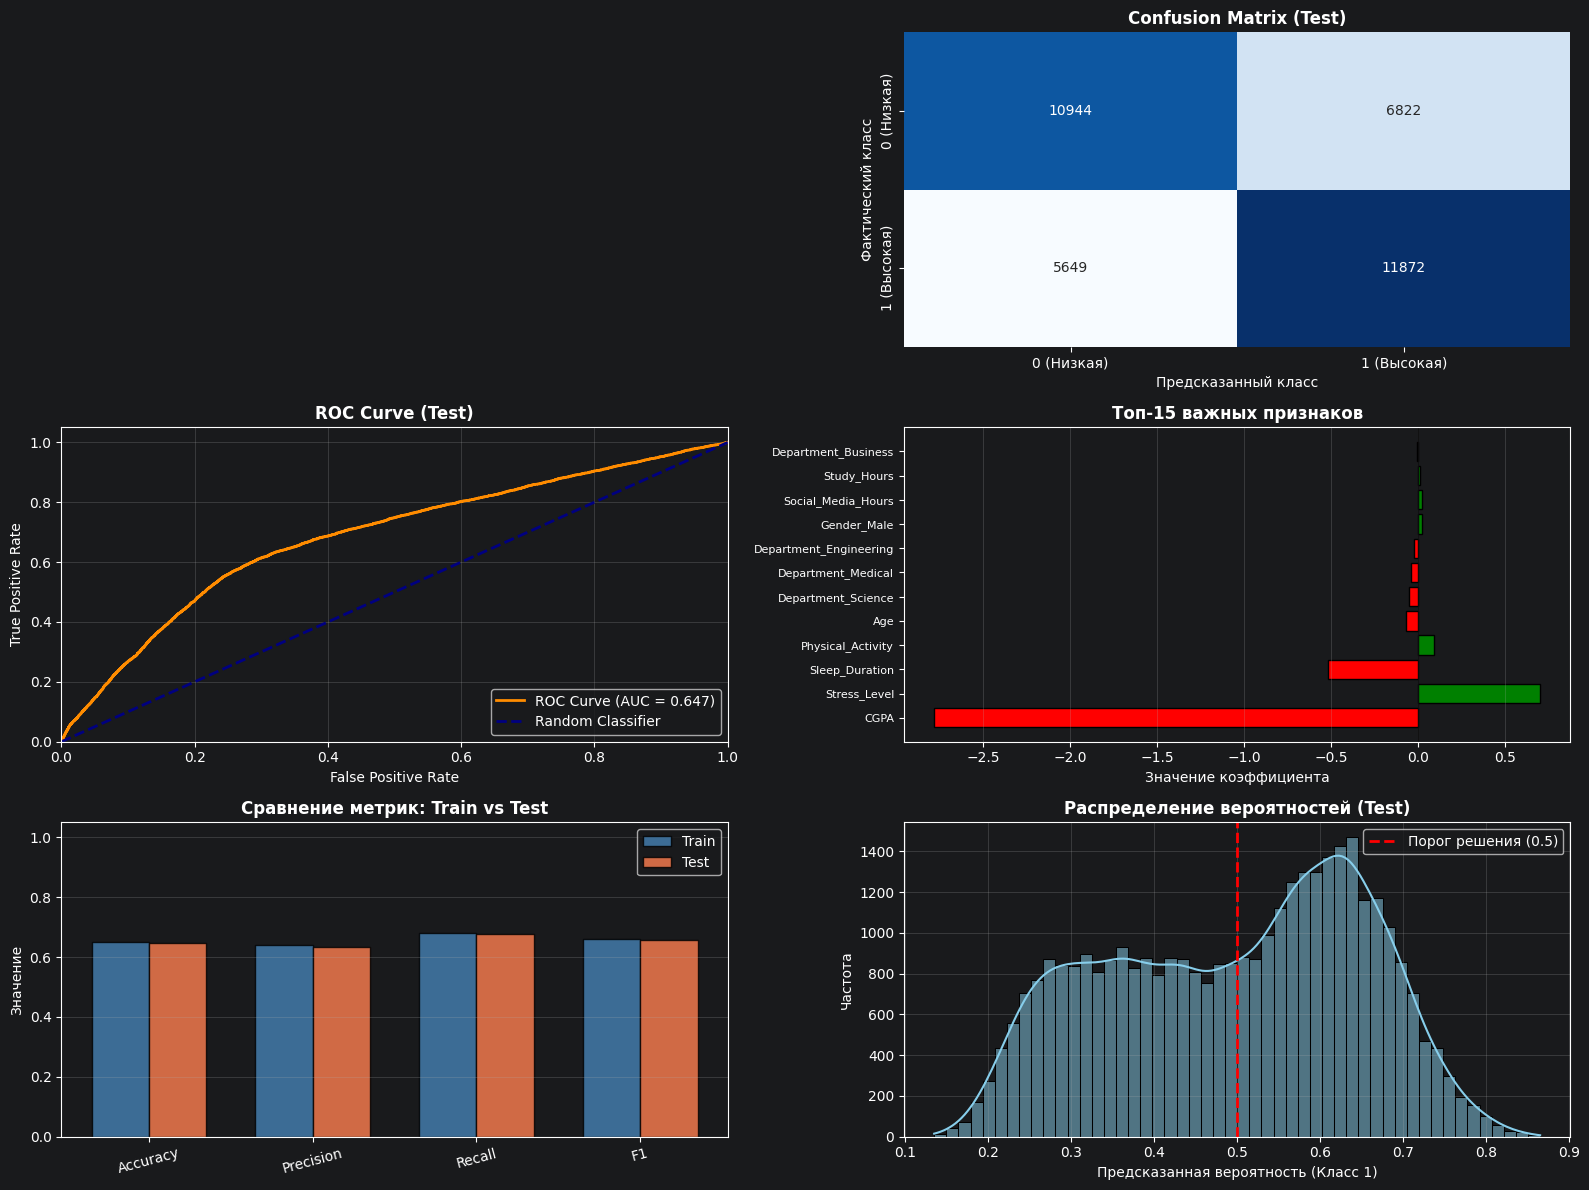

In [676]:
fig = plt.figure(figsize=(16, 12))

# ax1 = plt.subplot(3, 2, 1)
# ax1.plot(range(1, n_epochs + 1), loss_history, 'o-', color='darkorange', linewidth=2, label='Train Log Loss')
# ax1.set_xlabel('Эпоха', fontsize=10)
# ax1.set_ylabel('Log Loss', fontsize=10)
# ax1.set_title('Сходимость: Log Loss по эпохам', fontsize=12, fontweight='bold')
# ax1.legend(loc='upper right')
# ax1.grid(True, alpha=0.3)

ax2 = plt.subplot(3, 2, 2)
cm = confusion_matrix(y_test, y_test_predict)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2, cbar=False)
ax2.set_xlabel('Предсказанный класс', fontsize=10)
ax2.set_ylabel('Фактический класс', fontsize=10)
ax2.set_title('Confusion Matrix (Test)', fontsize=12, fontweight='bold')
ax2.set_xticklabels(['0 (Низкая)', '1 (Высокая)'])
ax2.set_yticklabels(['0 (Низкая)', '1 (Высокая)'])

ax3 = plt.subplot(3, 2, 3)
fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
ax3.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {test_metrics["AUC-ROC"]:.3f})')
ax3.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax3.set_xlim([0.0, 1.0])
ax3.set_ylim([0.0, 1.05])
ax3.set_xlabel('False Positive Rate', fontsize=10)
ax3.set_ylabel('True Positive Rate', fontsize=10)
ax3.set_title('ROC Curve (Test)', fontsize=12, fontweight='bold')
ax3.legend(loc="lower right")
ax3.grid(True, alpha=0.3)

ax4 = plt.subplot(3, 2, 4)
weights_df = pd.DataFrame({
    'feature': X.columns,
    'weight': model.coef_[0]
})
weights_df = weights_df.sort_values(by='weight', key=lambda x: np.abs(x), ascending=False).head(15)

colors = ['green' if w > 0 else 'red' for w in weights_df['weight']]
bars = ax4.barh(weights_df['feature'], weights_df['weight'], color=colors, edgecolor='black')
ax4.set_xlabel('Значение коэффициента', fontsize=10)
ax4.set_title('Топ-15 важных признаков', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')
ax4.axvline(x=0, color='black', lw=0.5)
plt.setp(ax4.get_yticklabels(), fontsize=8)

ax5 = plt.subplot(3, 2, 5)
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1']
x_pos = np.arange(len(metrics_names))
width = 0.35

train_vals = [train_metrics['Accuracy'], train_metrics['Precision'], train_metrics['Recall'], train_metrics['F1']]
test_vals = [test_metrics['Accuracy'], test_metrics['Precision'], test_metrics['Recall'], test_metrics['F1']]

ax5.bar(x_pos - width / 2, train_vals, width, label='Train', alpha=0.8, edgecolor='black', color='steelblue')
ax5.bar(x_pos + width / 2, test_vals, width, label='Test', alpha=0.8, edgecolor='black', color='coral')
ax5.set_xticks(x_pos)
ax5.set_xticklabels(metrics_names, rotation=15)
ax5.set_ylabel('Значение', fontsize=10)
ax5.set_title('Сравнение метрик: Train vs Test', fontsize=12, fontweight='bold')
ax5.set_ylim(0, 1.05)
ax5.legend()
ax5.grid(True, alpha=0.3, axis='y')

ax6 = plt.subplot(3, 2, 6)
sns.histplot(y_test_proba, bins=50, kde=True, ax=ax6, color='skyblue', edgecolor='black')
ax6.axvline(x=0.5, color='red', linestyle='--', lw=2, label='Порог решения (0.5)')
ax6.set_xlabel('Предсказанная вероятность (Класс 1)', fontsize=10)
ax6.set_ylabel('Частота', fontsize=10)
ax6.set_title('Распределение вероятностей (Test)', fontsize=12, fontweight='bold')
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('logistic_regression_results.png', dpi=300, bbox_inches='tight')
plt.show()